In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS8_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff', block=3)

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


In [4]:
def plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            for i, mouse in enumerate(mice):
                data = block_rate.activity_rates[cond][mouse][day]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

/tmp/ipykernel_433230/1042546577.py:69: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
/tmp/ipykernel_433230/1042546577.py:69: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')


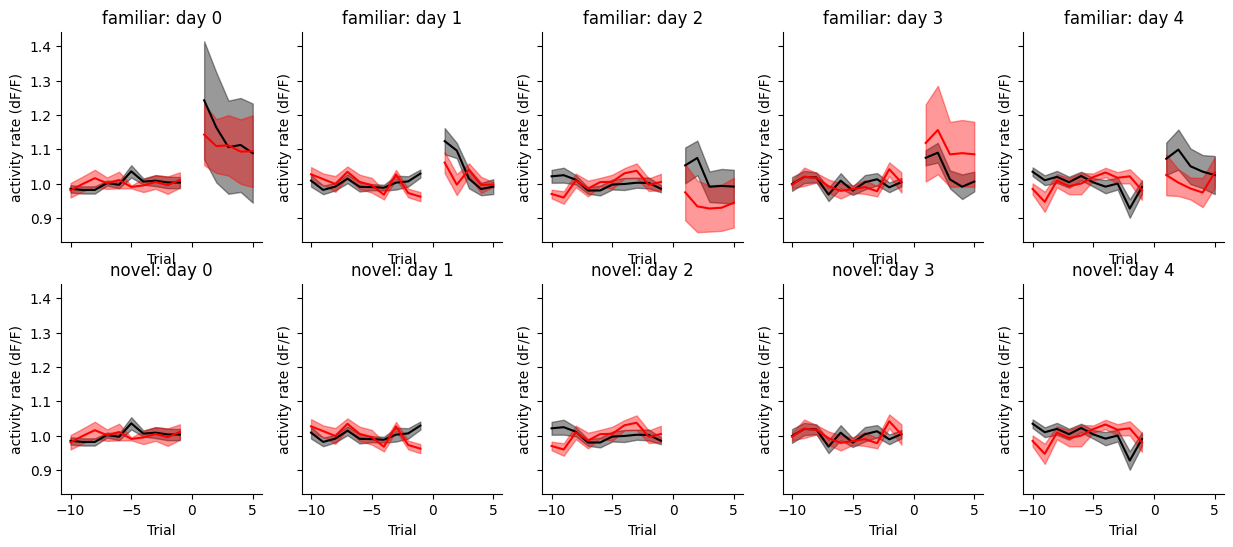

In [9]:
fig, ax = plot_block_avg(block_rate, norm = 'population', max_trial=5)
fig.savefig(figdir / 'block3_activity_rate.pdf')

In [10]:
df = block_rate.build_dataframe(max_trial=5, norm='population', norm_behavior=True)
df = df.loc[(df['day']<5) * df['ttype'].isin(('familiar', 'novel'))]

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:164: RuntimeWarning: Mean of empty slice.
  'novel': nov.mean()}
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:167: RuntimeWarning: Mean of empty slice.
  'novel': nov_speed.mean()}
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:170: RuntimeWarning: Mean of empty slice.
  'novel': nov_licks.mean()}


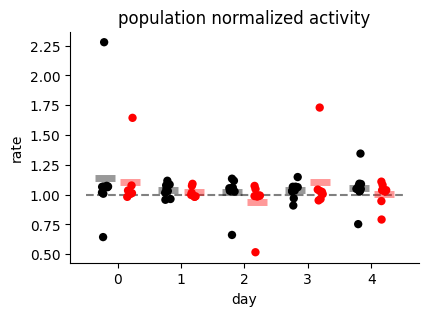

In [12]:
fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

sns.stripplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='rate',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)


sns.pointplot(data=df.loc[df['ttype'].isin(('familiar','novel')),:],
            x='day',
            y='rate',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


#
ax.set_title('population normalized activity')
ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(figdir / 'block3_activity_rate_by_day.pdf', bbox_inches='tight')
